In [7]:
import pandas as pd 

In [8]:
df = pd.read_csv('../data/Walmart.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [10]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[us]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(2)
memory usage: 402.3 KB


In [11]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.isocalendar().week

In [12]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.0
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,2010.965035,6.447552,25.818182
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,2010.000000,1.000000,1.0
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,2010.000000,4.000000,14.0
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,2011.000000,6.000000,26.0
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,2012.000000,9.000000,38.0
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000,2012.000000,12.000000,52.0
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,0.797019,3.238308,14.129201


In [13]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum()
store_sales.sort_values(ascending =False)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
19    2.066349e+08
31    1.996139e+08
23    1.987506e+08
24    1.940160e+08
11    1.939628e+08
28    1.892637e+08
41    1.813419e+08
32    1.668192e+08
18    1.551147e+08
22    1.470756e+08
12    1.442872e+08
26    1.434164e+08
34    1.382498e+08
40    1.378703e+08
35    1.315207e+08
8     1.299512e+08
17    1.277821e+08
45    1.123953e+08
21    1.081179e+08
25    1.010612e+08
43    9.056544e+07
15    8.913368e+07
7     8.159828e+07
42    7.956575e+07
9     7.778922e+07
29    7.714155e+07
16    7.425243e+07
37    7.420274e+07
30    6.271689e+07
3     5.758674e+07
38    5.515963e+07
36    5.341221e+07
5     4.547569e+07
44    4.329309e+07
33    3.716022e+07
Name: Weekly_Sales, dtype: float64

## VISUALIZATIONS 📊

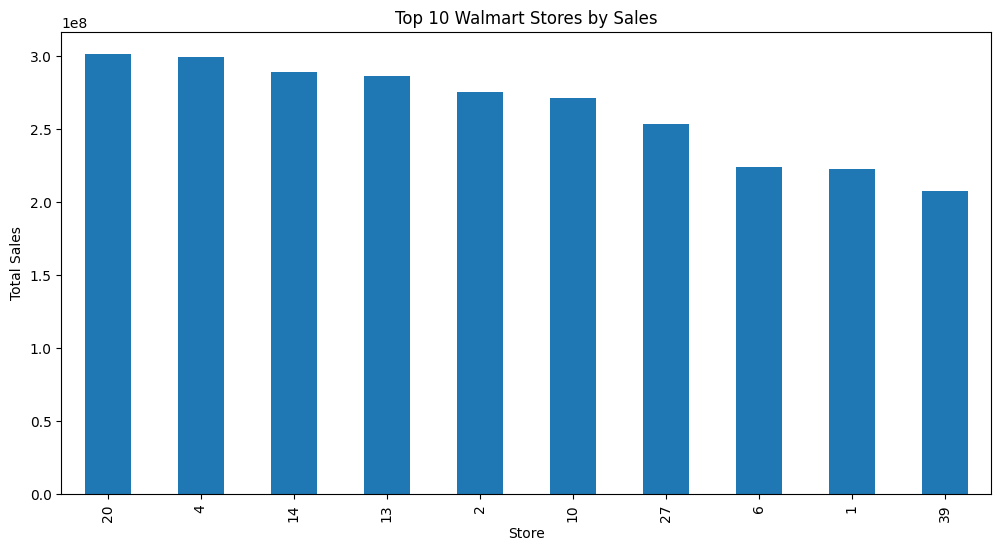

In [14]:
import matplotlib.pyplot as plt

top10 = store_sales.sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
top10.plot(kind='bar')
plt.title('Top 10 Walmart Stores by Sales')
plt.xlabel('Store')
plt.ylabel('Total Sales')
plt.show()

In [15]:
monthly_sales= df.groupby('month')['Weekly_Sales'].sum()
monthly_sales

month
1     3.325984e+08
2     5.687279e+08
3     5.927859e+08
4     6.468598e+08
5     5.571256e+08
6     6.226299e+08
7     6.500010e+08
8     6.130902e+08
9     5.787612e+08
10    5.847848e+08
11    4.130157e+08
12    5.768386e+08
Name: Weekly_Sales, dtype: float64

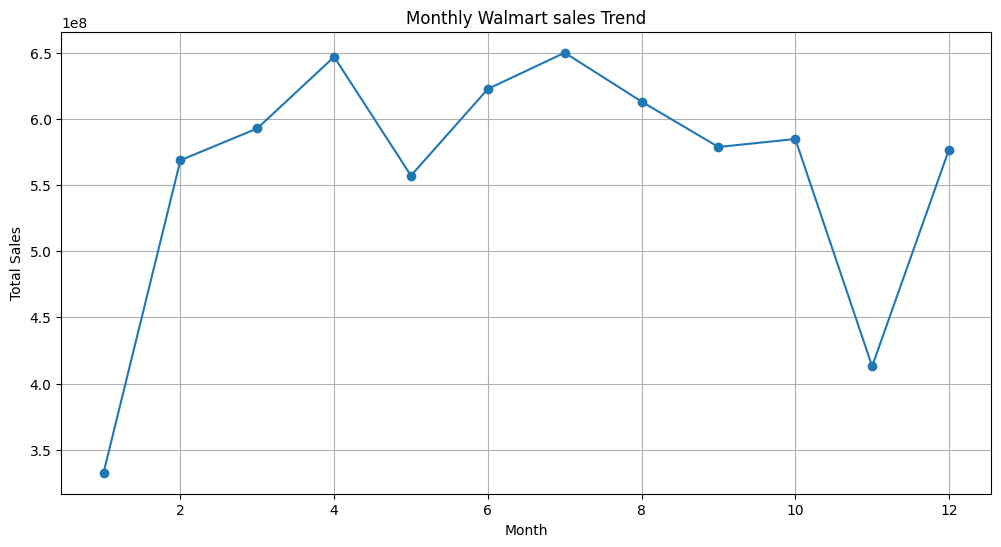

In [16]:
plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line',marker='o')
plt.title('Monthly Walmart sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

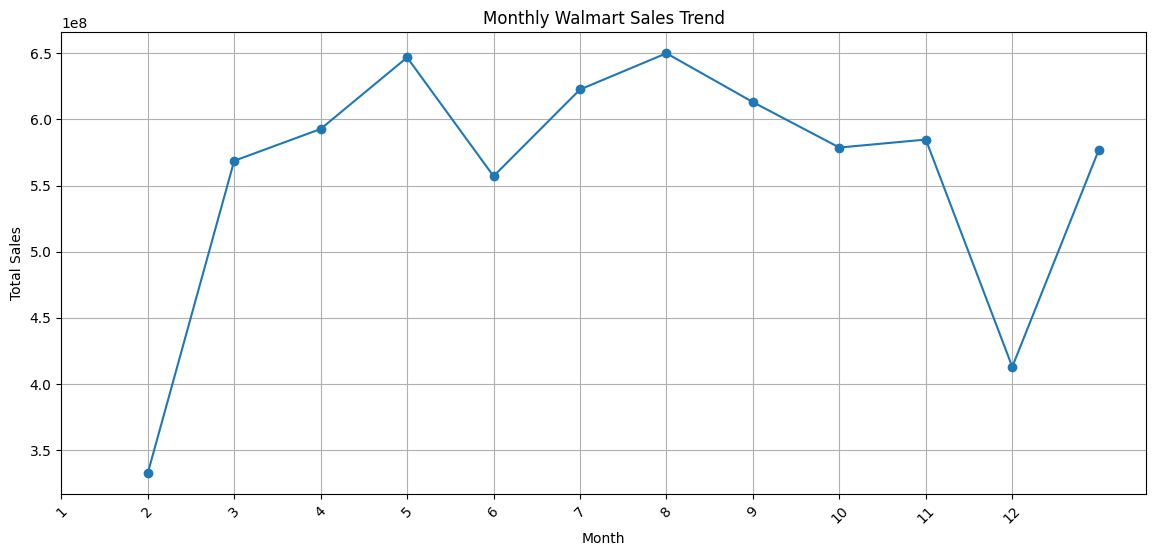

In [17]:
plt.figure(figsize=(14,6))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Walmart Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(
    ticks=range(len(monthly_sales.index)),
    labels=monthly_sales.index,
    rotation=45
)

plt.grid(True)

plt.show()

In [18]:
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
holiday_sales


Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64

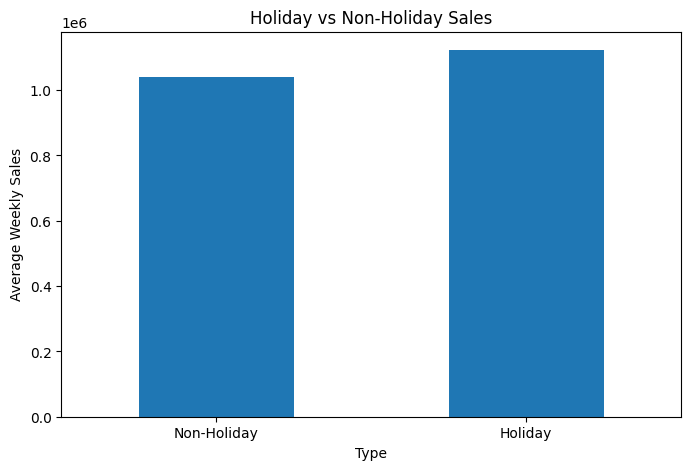

In [19]:
holiday_sales.index = ['Non-Holiday','Holiday']
plt.figure(figsize=(8,5))
holiday_sales.plot(kind='bar')
plt.title('Holiday vs Non-Holiday Sales')
plt.xlabel('Type')
plt.ylabel('Average Weekly Sales')

plt.xticks(rotation=0)
plt.show()

In [20]:
correlation = df.corr(numeric_only=True)
correlation

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week
Store,1.000000e+00,-0.335332,-4.386841e-16,-0.022659,0.060023,-0.209492,0.223531,3.474318e-12,2.910676e-15,3.106283e-15
Weekly_Sales,-3.353320e-01,1.000000,3.689097e-02,-0.063810,0.009464,-0.072634,-0.106176,-1.837754e-02,7.614332e-02,7.421127e-02
Holiday_Flag,-4.386841e-16,0.036891,1.000000e+00,-0.155091,-0.078347,-0.002162,0.010960,-5.678257e-02,1.229958e-01,1.277427e-01
Temperature,-2.265908e-02,-0.063810,-1.550913e-01,1.000000,0.144982,0.176888,0.101158,6.426923e-02,2.358618e-01,2.361833e-01
Fuel_Price,6.002295e-02,0.009464,-7.834652e-02,0.144982,1.000000,-0.170642,-0.034684,7.794703e-01,-4.215590e-02,-3.240300e-02
CPI,-2.094919e-01,-0.072634,-2.162091e-03,0.176888,-0.170642,1.000000,-0.302020,7.479573e-02,4.979672e-03,6.041530e-03
Unemployment,2.235313e-01,-0.106176,1.096028e-02,0.101158,-0.034684,-0.302020,1.000000,-2.418135e-01,-1.274559e-02,-1.589158e-02
year,3.474318e-12,-0.018378,-5.678257e-02,0.064269,0.779470,0.074796,-0.241813,1.000000e+00,-1.944645e-01,-1.819189e-01
month,2.910676e-15,0.076143,1.229958e-01,0.235862,-0.042156,0.004980,-0.012746,-1.944645e-01,1.000000e+00,9.959843e-01
week,3.106283e-15,0.074211,1.277427e-01,0.236183,-0.032403,0.006042,-0.015892,-1.819189e-01,9.959843e-01,1.000000e+00


### CORRELATION ANALYSIS

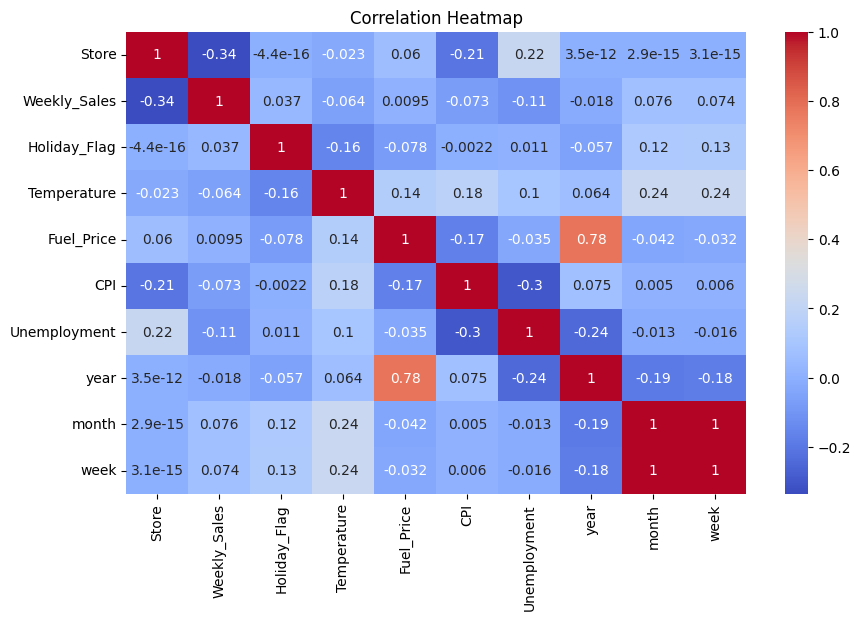

In [21]:
import seaborn as sns 
plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

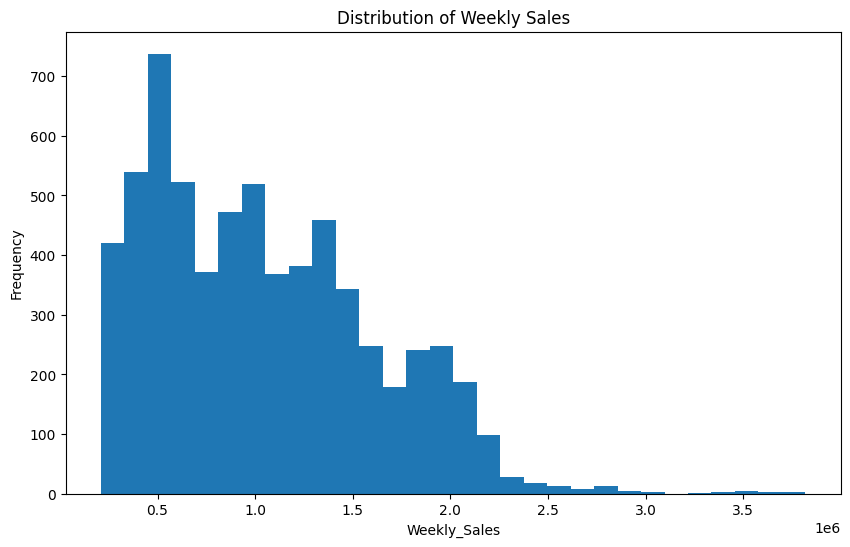

In [22]:
plt.figure(figsize=(10,6))
plt.hist(df['Weekly_Sales'], bins=30)
plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly_Sales')
plt.ylabel('Frequency')
plt.show()

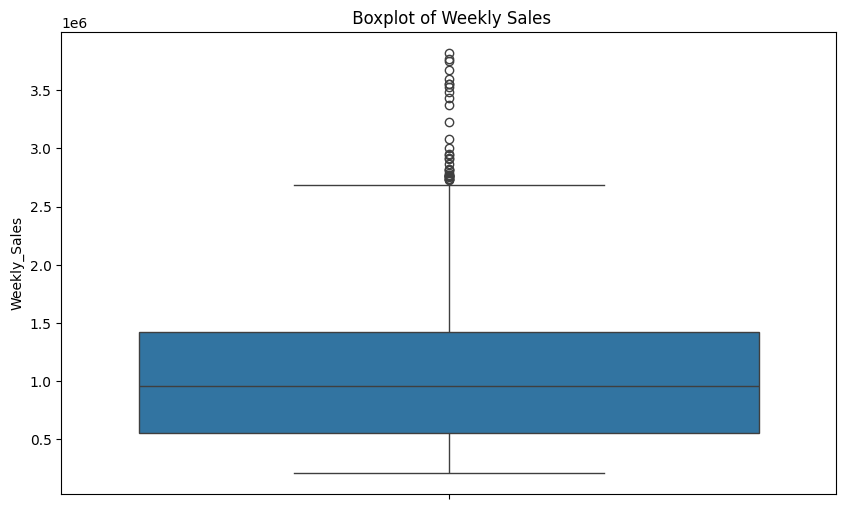

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(df['Weekly_Sales'])
plt.title(' Boxplot of Weekly Sales')
plt.show()

Multiple High-Sales Outliers

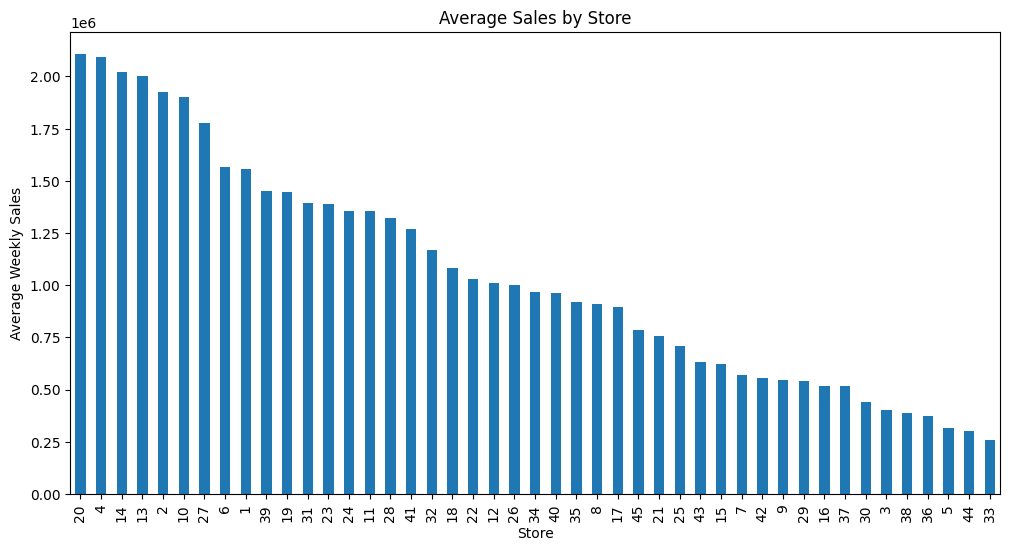

In [24]:
store_avg_sales = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
store_avg_sales.plot(kind='bar')

plt.title('Average Sales by Store')
plt.xlabel('Store')
plt.ylabel('Average Weekly Sales')
plt.show()

### YEARLY SALES TREND 📈

How sales changed across years

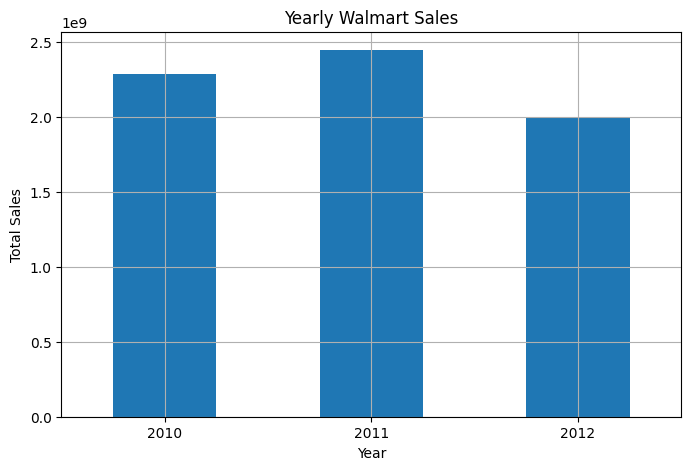

In [25]:
yearly_sales = df.groupby('year')['Weekly_Sales'].sum()

plt.figure(figsize=(8,5))

yearly_sales.plot( 
    kind = 'bar',
)

plt.title('Yearly Walmart Sales')
plt.xlabel('Year')
plt.ylabel('Total Sales')

plt.xticks(rotation = 0)

plt.grid(True)
plt.show()

### TEMPERATURE vs SALES 🌡️

Business + Environmental Analytics

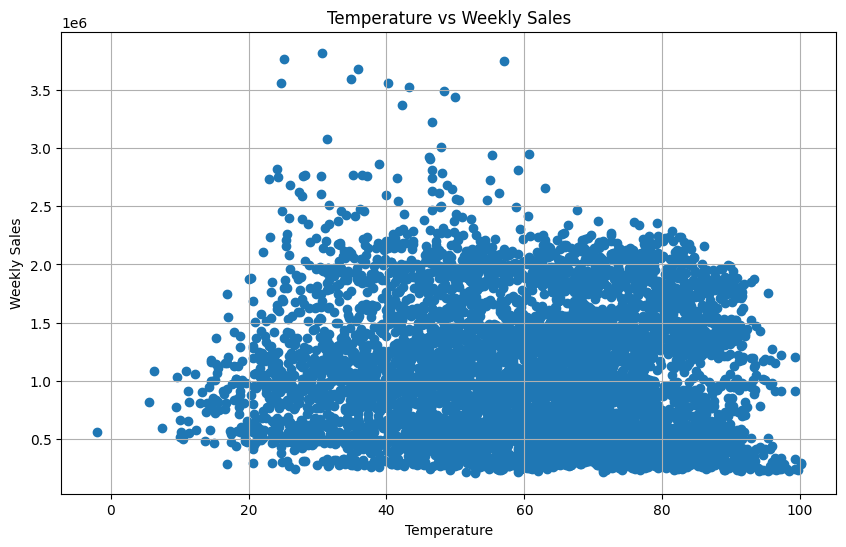

In [26]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Temperature'],
    df['Weekly_Sales']
)

plt.title('Temperature vs Weekly Sales')

plt.xlabel('Temperature')
plt.ylabel('Weekly Sales')

plt.grid(True)

plt.show()

### FUEL PRICE vs SALES ⛽

Economic impact on customer spending

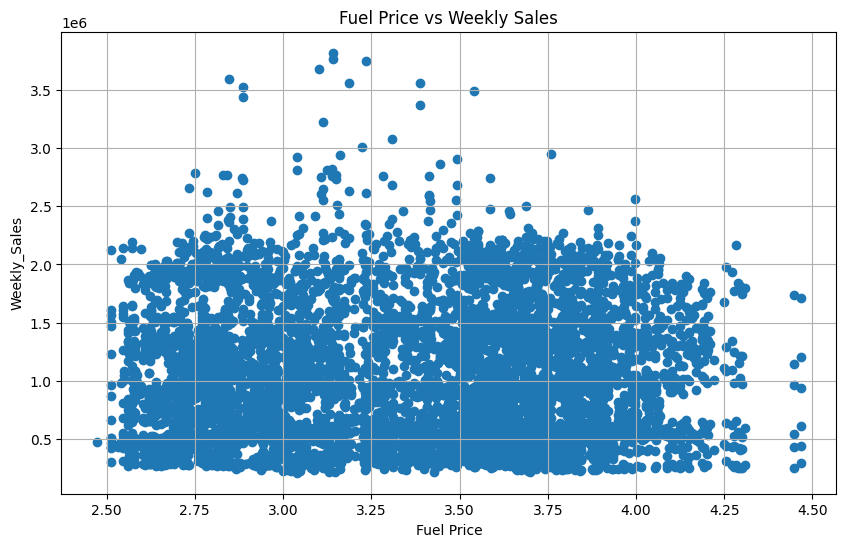

In [28]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Fuel_Price'],
    df['Weekly_Sales']
)

plt.title('Fuel Price vs Weekly Sales')

plt.xlabel('Fuel Price')
plt.ylabel('Weekly_Sales')

plt.grid(True)

plt.show()

### CPI vs SALES 📈

Inflation impact on retail sales

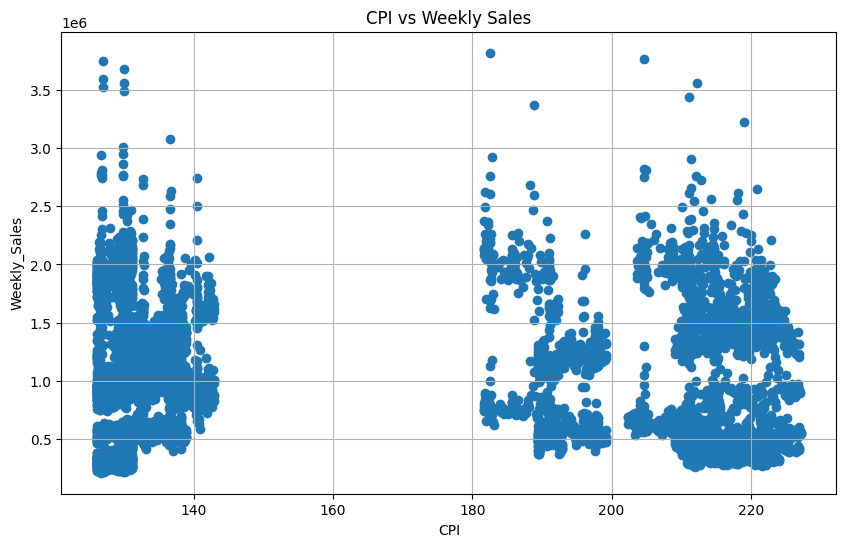

In [31]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['CPI'],
    df['Weekly_Sales']
)

plt.title('CPI vs Weekly Sales')

plt.xlabel('CPI')
plt.ylabel('Weekly_Sales')

plt.grid(True)

plt.show()

### UNEMPLOYMENT vs SALES 📉

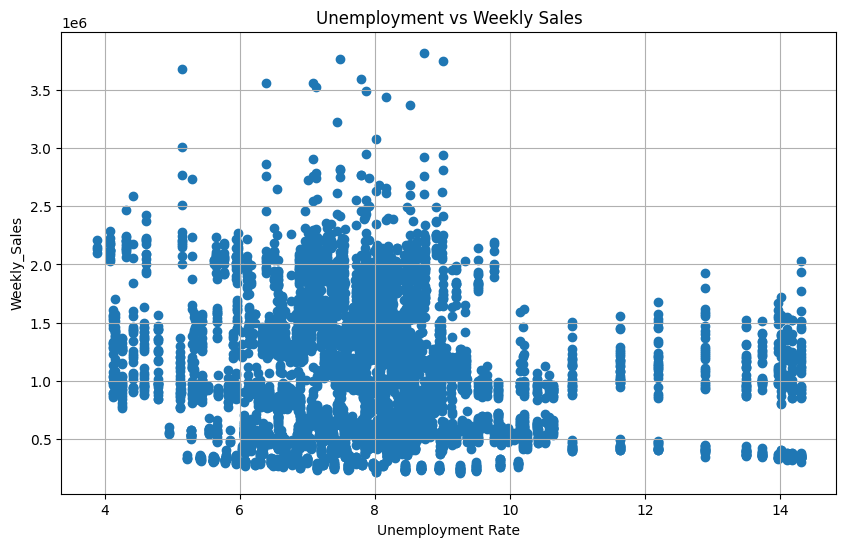

In [33]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Unemployment'],
    df['Weekly_Sales']
)

plt.title('Unemployment vs Weekly Sales')

plt.xlabel('Unemployment Rate')
plt.ylabel('Weekly_Sales')

plt.grid(True)

plt.show()

Customer purchasing power weakens slightly during higher unemployment periods

In [34]:
df.to_csv('../exports/walmart_cleaned.csv',index=False)
print("Cleaned dataset exported Successfully")

Cleaned dataset exported Successfully
